In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch import nn
from torch.utils.data import DataLoader
import copy
import time
from modules import func, networks
import math

In [10]:
# Conv4 + CIFAR10 experiment settings
BATCH_SIZE = 128
MAX_ITERS = 5000
LR = 1.3e-3
VALSIZE = 5000
NUM_CLASSES = 10
PRUNE_RATE = 0.10
PRUNE_ROUNDS = 12

# Base Conv4 widths (scaled-down VGG style)
C1, C2, C3, C4 = 64, 64, 128, 128
FC1, FC2 = 256, 256

In [11]:
import ssl
import platform

# macOS Python (python.org installer) ships without system SSL certs wired up.
# This patches the default HTTPS context so torchvision dataset downloads work.
# Safe to run on any OS — it's a no-op on Colab/Linux where certs are already fine.
if platform.system() == "Darwin":
    ssl._create_default_https_context = ssl._create_unverified_context

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>

In [ ]:
targets = np.array(full_train_data.targets)
idx = np.arange(len(full_train_data))

train_idx, val_idx = train_test_split(
    idx,
    test_size=VALSIZE,
    stratify=targets,
    random_state=42,
    shuffle=True,
)

train_data = Subset(full_train_data, train_idx)
val_data = Subset(full_train_data, val_idx)

In [ ]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


mps


In [ ]:
model = networks.Conv4(C1, C2, C3, C4, FC1, FC2, num_classes=NUM_CLASSES).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def get_prunable_layers(m):
    return [m.conv1, m.conv2, m.conv3, m.conv4, m.fc1, m.fc2, m.fc3]


def clone_ticket(m):
    return [[layer.weight.data.clone(), layer.bias.data.clone()] for layer in get_prunable_layers(m)]


def load_ticket(m, ticket):
    for (w, b), layer in zip(ticket, get_prunable_layers(m)):
        layer.weight.data = w.clone()
        layer.bias.data = b.clone()


def model_size_bytes(m):
    return sum(p.nelement() * p.element_size() for p in m.parameters())


def benchmark_inference_ms(m, dataloader, device, batches=20, warmup=5):
    m.eval()
    batch_times = []
    with torch.no_grad():
        for i, (X, _) in enumerate(dataloader):
            if i >= warmup + batches:
                break
            X = X.to(device)
            if device == "cuda":
                torch.cuda.synchronize()
            start = torch.cuda.Event(enable_timing=True) if device == "cuda" else None
            end = torch.cuda.Event(enable_timing=True) if device == "cuda" else None

            if device == "cuda":
                start.record()
                _ = m(X)
                end.record()
                torch.cuda.synchronize()
                elapsed = start.elapsed_time(end)
            else:
                t0 = time.perf_counter()
                _ = m(X)
                elapsed = (time.perf_counter() - t0) * 1000.0

            if i >= warmup:
                batch_times.append(elapsed)

    return float(np.mean(batch_times)) if batch_times else float("nan")

In [ ]:
# Save dense initialization as the lottery ticket source
original = clone_ticket(model)

# Track results across pruning rounds
results = []

for round_idx in range(PRUNE_ROUNDS + 1):
    train_start = time.perf_counter()
    best_iter = networks.trainIter(
        train_dataloader,
        val_dataloader,
        model,
        loss_fn,
        optimizer,
        device,
        MAX_ITERS,
        Verbose=False,
    )
    train_time_s = time.perf_counter() - train_start

    acc = networks.test(test_dataloader, model, loss_fn, device)
    infer_ms = benchmark_inference_ms(model, test_dataloader, device)
    size_mb = model_size_bytes(model) / (1024 * 1024)

    c1 = original[0][0].shape[0]
    c2 = original[1][0].shape[0]
    c3 = original[2][0].shape[0]
    c4 = original[3][0].shape[0]
    fc1_size = original[4][0].shape[0]
    fc2_size = original[5][0].shape[0]

    results.append({
        "round": round_idx,
        "best_iter": best_iter,
        "acc": acc,
        "train_time_s": train_time_s,
        "infer_ms_per_batch": infer_ms,
        "model_size_mb": size_mb,
        "c1": c1,
        "c2": c2,
        "c3": c3,
        "c4": c4,
        "fc1": fc1_size,
        "fc2": fc2_size,
    })

    # Last round: report only, do not prune further.
    if round_idx == PRUNE_ROUNDS:
        break

    # Use trained weights to rank conv filters by magnitude importance
    saved = clone_ticket(model)
    ranked_conv = func.least_conv_filters(saved)

    n_to_prune = max(1, int(len(ranked_conv) * PRUNE_RATE))

    # Apply removals to the ORIGINAL initialization ticket (LTH reset step)
    # Recompute ranking every removal because indices shift after structural deletes.
    for _ in range(n_to_prune):
        ranked_current = func.least_conv_filters(saved)
        lyr, nrn, _ = ranked_current[0]

        func.remove_4d(saved, lyr, nrn)
        func.remove_4d(original, lyr, nrn)

    # Rebuild a physically smaller Conv4 using pruned dimensions
    c1 = original[0][0].shape[0]
    c2 = original[1][0].shape[0]
    c3 = original[2][0].shape[0]
    c4 = original[3][0].shape[0]
    fc1_size = original[4][0].shape[0]
    fc2_size = original[5][0].shape[0]

    model = networks.Conv4(c1, c2, c3, c4, fc1_size, fc2_size, num_classes=NUM_CLASSES).to(device)
    load_ticket(model, original)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

out = [(r["best_iter"], r["acc"]) for r in results]
results

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.100823 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.099182 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.099182 

Test Error: 
 Accuracy: 97.0%, Avg loss: 0.099182 



KeyboardInterrupt: 

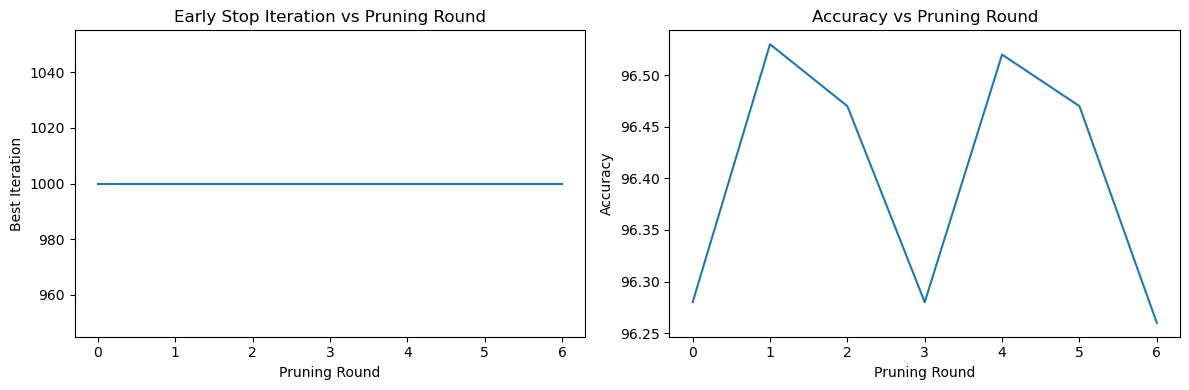

In [ ]:
rounds = [r["round"] for r in results]
accs = [r["acc"] for r in results]
train_times = [r["train_time_s"] for r in results]
infer_times = [r["infer_ms_per_batch"] for r in results]
sizes = [r["model_size_mb"] for r in results]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(rounds, accs)
axes[0, 0].set_title("Accuracy vs Pruning Round")
axes[0, 0].set_xlabel("Pruning Round")
axes[0, 0].set_ylabel("Accuracy (%)")

axes[0, 1].plot(rounds, train_times)
axes[0, 1].set_title("Training Time vs Pruning Round")
axes[0, 1].set_xlabel("Pruning Round")
axes[0, 1].set_ylabel("Training Time (s)")

axes[1, 0].plot(rounds, infer_times)
axes[1, 0].set_title("Inference Speed vs Pruning Round")
axes[1, 0].set_xlabel("Pruning Round")
axes[1, 0].set_ylabel("Inference Time (ms/batch)")

axes[1, 1].plot(rounds, sizes)
axes[1, 1].set_title("Model Size vs Pruning Round")
axes[1, 1].set_xlabel("Pruning Round")
axes[1, 1].set_ylabel("Model Size (MB)")

plt.tight_layout()
plt.show()

In [ ]:
''''
model.eval()
i = 10
x, y = test_data[i][0], test_data[i][1]
with torch.no_grad():
    x=x.to(device)
    logits = model(x.to(device))
    probs = torch.softmax(logits, dim=1)
    predicted, actual, c = probs[0].argmax(0), y, probs[0]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')
    print(c)
'''

Predicted: "0", Actual: "0"
tensor([1.0000e+00, 1.8123e-16, 3.3264e-12, 1.0189e-16, 1.6449e-14, 2.4744e-16,
        5.7396e-13, 1.0295e-14, 1.6308e-15, 5.3495e-11], device='mps:0')
